# **Исследование методов эффективного применения адаптеров (LoRA)  для дообучения моделей в условиях ограниченных вычислительных ресурсов**

**Содержание работы:**
1. EDA (AG News) - **EN**
2. Эксперименты с моделью **Qwen3-0.6B**:
- Эксперимент 1 - Baseline
  - эксперимент проводится 5 раз для датасета в объеме 30000 / 15000 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки соответсвенно
- Эксперимент 2 - LoRA
  - эксперимент проводится 5 раз для датасета в объеме 30000 / 15000 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки соответсвенно
- Эксперимент 3 - QLoRA
  - эксперимент проводится 5 раз для датасета в объеме 30000 / 15000 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки соответсвенно
- Эксперимент 4 - OrthoGeoLoRA
  - эксперимент проводится 3 раза для датасета в объеме 30000 / 15000 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки соответсвенно

# Настройка окружения и инициализация

In [1]:
!pip install transformers accelerate peft datasets evaluate bitsandbytes


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
%pip -q install "transformers>=4.43" "datasets>=2.18" "accelerate>=0.33" "trl>=0.9" "bitsandbytes>=0.45"

import os, random, math, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    DataCollatorForLanguageModeling
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.cuda.is_available())

MODEL_NAME = "Qwen/Qwen3-0.6B"

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print("device:", device, "| dtype:", DTYPE)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
True
device: cuda | dtype: torch.bfloat16


In [3]:
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score
import evaluate

# **EDA (AG News)**

- Загрузка датасета - Классификация на AG News
- EDA (размеры, классы, длины, графики)

In [4]:
# Загрузка датасета
ds = load_dataset("ag_news")

label_map = ["World", "Sports", "Business", "Sci/Tech"]
num_labels = 4

'_ssl.c:1015: The handshake operation timed out' thrown while requesting HEAD https://huggingface.co/datasets/ag_news/resolve/eb185aade064a813bc0b7f42de02595523103ca4/ag_news.py
Retrying in 1s [Retry 1/5].
'_ssl.c:1015: The handshake operation timed out' thrown while requesting HEAD https://huggingface.co/datasets/ag_news/resolve/eb185aade064a813bc0b7f42de02595523103ca4/ag_news.py
Retrying in 2s [Retry 2/5].


In [5]:
train = ds["train"]
test = ds["test"]

print("Список колонок:")
print(ds.column_names)

print("\nРазмер датасета:")
print(ds.shape)

# Три случайных примера из train
print("\nТри случайных примера:")
import random

random_indices = random.sample(range(len(train)), 3)

for idx in random_indices:
    example = train[idx]
    print(f"\nПример {idx}:")
    print(f"Text: {example['text']}")
    print(f"Label: {example['label']}")

Список колонок:
{'train': ['text', 'label'], 'test': ['text', 'label']}

Размер датасета:
{'train': (120000, 2), 'test': (7600, 2)}

Три случайных примера:

Пример 83810:
Text: Policeman 'saw fatal train crash' An off-duty policeman watched a train plough into a car on a level crossing  in Berkshire, killing six people.
Label: 0

Пример 14592:
Text: Silver finale for USA In the last event of the 2004 Olympic Games, the United States track team produced one last surprise. Meb Keflezighi, a native of Eritrea who moved to the United States as 
Label: 1

Пример 3278:
Text: Compuware Blasts IBM #39;s Legal Tactics Two years ago, IBM was ordered to produce the source code for its products, which Compuware identified as containing its pirated intellectual property. The code was missing. But lo and behold -- last week, they called and said they had it, quot; ...
Label: 3


Train size: 120000
Test size:  7600

Columns: ['text', 'label']

Class distribution (train):
label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64

Class distribution (test):
label
2    1900
3    1900
1    1900
0    1900
Name: count, dtype: int64

Average text length (train): 236.5 characters
Average text length (test):  235.3 characters
Text length range (train): 100 - 1012
Text length range (test):  100 - 892


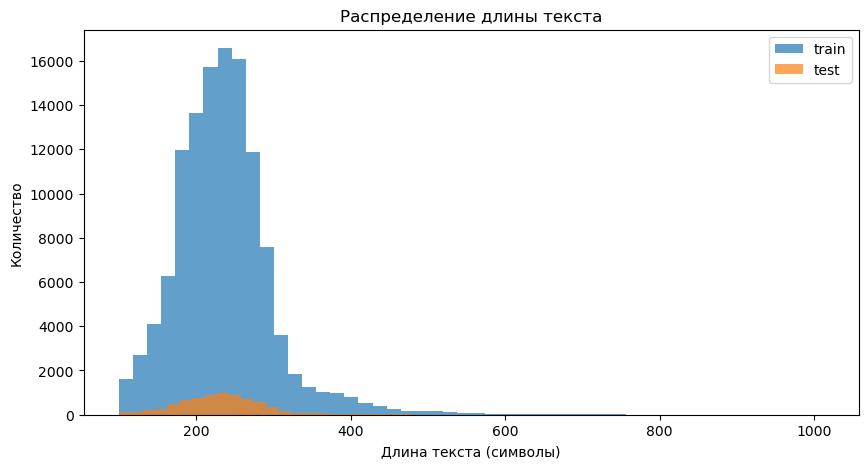

In [6]:
# Преобразуем в DataFrame для удобной статистики
df_train = pd.DataFrame(train)
df_test  = pd.DataFrame(test)

# Размеры датасета
print(f"Train size: {len(df_train)}")
print(f"Test size:  {len(df_test)}")

# Список колонок
print("\nColumns:", df_train.columns.tolist())

# Распределение классов
print("\nClass distribution (train):")
print(df_train['label'].value_counts())

print("\nClass distribution (test):")
print(df_test['label'].value_counts())

# Средняя длина текста
df_train['text_len'] = df_train['text'].apply(len)
df_test['text_len']  = df_test['text'].apply(len)

print(f"\nAverage text length (train): {df_train['text_len'].mean():.1f} characters")
print(f"Average text length (test):  {df_test['text_len'].mean():.1f} characters")

# Минимальная и максимальная длина текста
print(f"Text length range (train): {df_train['text_len'].min()} - {df_train['text_len'].max()}")
print(f"Text length range (test):  {df_test['text_len'].min()} - {df_test['text_len'].max()}")

# Визуализация распределения длины текста
plt.figure(figsize=(10,5))
plt.hist(df_train['text_len'], bins=50, alpha=0.7, label='train')
plt.hist(df_test['text_len'], bins=50, alpha=0.7, label='test')
plt.xlabel("Длина текста (символы)")
plt.ylabel("Количество")
plt.title("Распределение длины текста")
plt.legend()
plt.show()

# Подготовка токенизатора

In [7]:
#Подготовка токенизатора
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Добавляем pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [8]:
def prepare_dataset(train=train, test=test, tokenize=tokenize, sample_frac=1.0, seed=42):
    """
    Подготовка датасета:
    - сэмплирование (% датасета)
    - токенизация
    - удаление лишних колонок
    - приведение label -> labels
    """

    # 1. Сэмплирование
    train_ds = train.shuffle(seed=seed).select(
        range(int(sample_frac * len(train)))
    )

    # 2. Токенизация
    train_tok = train_ds.map(tokenize, batched=True)
    test_tok = test.map(tokenize, batched=True)

    # 3. Удаление текста (если есть)
    if "text" in train_tok.column_names:
        train_tok = train_tok.remove_columns(["text"])
    if "text" in test_tok.column_names:
        test_tok = test_tok.remove_columns(["text"])

    # 4. label → labels (для Trainer)
    if "label" in train_tok.column_names:
        train_tok = train_tok.rename_column("label", "labels")
    if "label" in test_tok.column_names:
        test_tok = test_tok.rename_column("label", "labels")

    return train_tok, test_tok

# **Эксперимент 1 - Baseline**

**План эксперимента 1 - Baseline**:

- Определение функций для эксперимента
- Определение объема выборки
- Baseline-эксперимент:
  - загружается базовая модель Qwen3-0.6B
  - замораживаются все параметры, кроме классификационной головы
  - Trainer обучает 1 эпоху
  - собираются baseline-метрики

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- добавление baseline
- сохранение в lora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки 30000 / 15000 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 1

In [9]:
def load_base_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        torch_dtype=torch.float16,
        device_map="auto",
        ignore_mismatched_sizes=True
    )

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [11]:
# Заморозка модели (baseline)
def freeze_all_but_head(model):
    for name, param in model.named_parameters():
        if "classifier" not in name and "score" not in name:
            param.requires_grad = False
    return model


# Подсчёт trainable параметров
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Обучение + инференс
def train_and_predict(model, train_tok, test_tok, tokenizer):
    args = TrainingArguments(
        output_dir="./outputs/baseline",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    mid = time.time()

    pred_test = trainer.predict(test_tok)
    end = time.time()

    pred_train = trainer.predict(train_tok)

    return pred_train, pred_test, mid - start, end - mid


# Подсчёт метрик
def compute_full_metrics(pred):
    logits = pred.predictions
    labels = pred.label_ids
    preds = np.argmax(logits, axis=-1)

    loss = F.cross_entropy(
        torch.tensor(logits),
        torch.tensor(labels)
    ).item()

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
        "loss": loss
    }


# GPU метрики
def get_gpu_metrics():
    if torch.cuda.is_available():
        return {
            "gpu_memory_allocated_gb": torch.cuda.max_memory_allocated() / 1024**3,
            "gpu_memory_reserved_gb": torch.cuda.max_memory_reserved() / 1024**3,
        }
    return {
        "gpu_memory_allocated_gb": 0,
        "gpu_memory_reserved_gb": 0,
    }


# функция baseline
def run_baseline(train_tok, test_tok, tokenizer):
    print("\nЗапуск Baseline (только classification head)")

    model = load_base_model()
    model = freeze_all_but_head(model)

    print(f"Trainable parameters: {count_trainable_params(model):,}")

    pred_train, pred_test, time_train, time_eval = train_and_predict(
        model, train_tok, test_tok, tokenizer
    )

    train_metrics = compute_full_metrics(pred_train)
    test_metrics = compute_full_metrics(pred_test)
    gpu_metrics = get_gpu_metrics()

    return {
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_loss": train_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_f1": test_metrics["f1"],
        "test_loss": test_metrics["loss"],
        "time_sec_train": time_train,
        "time_sec_eval": time_eval,
        **gpu_metrics
    }

### **30000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

In [ ]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics

In [ ]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_baseline_100pct.csv", index=False)
print("\nРезультаты сохранены в qw3_baseline_100pct.csv")

### **15000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.5)

In [ ]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics

In [ ]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_baseline_50pct.csv", index=False)
print("\nРезультаты сохранены в qw3_baseline_50pct.csv")

### **8000 образцов в каждом классе обучающей выборки**

In [12]:
def sample_by_label(dataset, n_samples=8000, seed=42):
    unique_labels = set(dataset['label'])
    sampled_indices = []
    
    for label in unique_labels:
        label_indices = [i for i, lbl in enumerate(dataset['label']) if lbl == label]
        
        sampled = pd.Series(label_indices).sample(n=n_samples, random_state=seed)
        sampled_indices.extend(sampled.tolist())
    
    return dataset.select(sampled_indices)

train_8000 = sample_by_label(train, n_samples=8000, seed=42)

In [13]:
train_tok, test_tok = prepare_dataset(train=train_8000)

In [14]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.382327,0.379883,0.873816,0.873650


{'train_accuracy': 0.8760625,
 'train_f1': 0.8758614443089607,
 'train_loss': 0.381103515625,
 'test_accuracy': 0.8738157894736842,
 'test_f1': 0.8736495558446128,
 'test_loss': 0.379638671875,
 'time_sec_train': 347.68791031837463,
 'time_sec_eval': 63.147540807724,
 'gpu_memory_allocated_gb': 1.289412498474121,
 'gpu_memory_reserved_gb': 1.30078125}

In [15]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_baseline_8000_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_baseline_8000_v2.csv")


Результаты сохранены в qw3_baseline_8000_v2.csv


### **3000 образцов в каждом классе обучающей выборки**

In [41]:
train_tok, test_tok = prepare_dataset(sample_frac=0.1)

In [42]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.286369,0.412842,0.853816,0.853451


{'train_accuracy': 0.8543333333333333,
 'train_f1': 0.8537582784171075,
 'train_loss': 0.41259765625,
 'test_accuracy': 0.8538157894736842,
 'test_f1': 0.8534510180894366,
 'test_loss': 0.412841796875,
 'time_sec_train': 169.7777075767517,
 'time_sec_eval': 63.098689556121826,
 'gpu_memory_allocated_gb': 3.5700907707214355,
 'gpu_memory_reserved_gb': 3.603515625}

In [43]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_baseline_3000_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_baseline_3000_v2.csv")


Результаты сохранены в qw3_baseline_3000_v2.csv


### **1500 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.05)

In [ ]:
# Baseline: только classification head
print("\nЗапуск Baseline (только classification head)")
base_model = load_base_model()
# Замораживаем все слои кроме классификационной головы
for name, param in base_model.named_parameters():
    if "classifier" not in name and "score" not in name:
        param.requires_grad = False

print(f"Trainable parameters in baseline: {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}")

### **300 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.01)

In [ ]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics

In [ ]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_baseline_pct.csv", index=False)
print("\nРезультаты сохранены в qw3_baseline_1pct.csv")

# **Эксперимент 2 - LoRA**

**План эксперимента 2 - LoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в lora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки 100 / 50 / 10 / 5 / 1 %

### Функции для эксперимента 2

In [16]:
def create_lora_model(rank, target_modules):
    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )
    return get_peft_model(base, lora_cfg)

def create_training_args(rank, target_modules, output_dir="./outputs"):
    name = f"r{rank}_" + "-".join(target_modules)

    return TrainingArguments(
        output_dir=f"{output_dir}/{name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{name}/logs",
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

def run_experiment(rank, target_modules, output_dir="./outputs"):

    metrics = {}

    # Создаем модель
    model = create_lora_model(rank, target_modules)
    print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

    # Создаем аргументы для тренировки
    args = create_training_args(rank, target_modules, output_dir)

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **30000 образцов в каждом классе обучающей выборки**

In [45]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

In [46]:
# LoRA эксперименты
ranks = [4, 8]
modules_list = [
    ["q_proj", "v_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.269087,0.297363,0.936579,0.936581


...

Trainable parameters: 1,150,976


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.279318,0.292969,0.937368,0.937354


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 3323.1055779457092, 'time_sec_eval': 73.07971429824829, 'rank': 8, 'modules': 'q_proj-v_proj', 'gpu_memory_allocated_gb': 4.165557384490967, 'gpu_memory_reserved_gb': 4.251953125, 'trainable_parameters': 1150976, 'train_accuracy': 0.9474083333333333, 'train_f1': 0.9474285918666562, 'train_loss': 0.0, 'test_accuracy': 0.9373684210526316, 'test_f1': 0.937353938620671, 'test_loss': 0.29296875}


In [47]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_30000_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_30000_v2.csv")
df_results


Результаты сохранены в qw3_lora_results_30000_v2.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,3336.151861,73.615036,4,q_proj-v_proj,4.158294,4.224609,577536,0.945508,0.945527,0.0,0.936579,0.936581,0.297119
1,3323.105578,73.079714,8,q_proj-v_proj,4.165557,4.251953,1150976,0.947408,0.947429,0.0,0.937368,0.937354,0.292969


In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_100pct.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_100pct.csv")
df_results

In [ ]:
# LoRA эксперименты
ranks = [32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_100pct_32.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_100pct_32.csv")
df_results

### **8000 образцов в каждом классе обучающей выборки**

In [17]:
def sample_by_label(dataset, n_samples=8000, seed=42):
    unique_labels = set(dataset['label'])
    sampled_indices = []
    
    for label in unique_labels:
        label_indices = [i for i, lbl in enumerate(dataset['label']) if lbl == label]
        
        sampled = pd.Series(label_indices).sample(n=n_samples, random_state=seed)
        sampled_indices.extend(sampled.tolist())
    
    return dataset.select(sampled_indices)

train_8000 = sample_by_label(train, n_samples=8000, seed=42)

In [18]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

In [19]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.361521,0.338379,0.928158,0.928129


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.291021,0.292480,0.935132,0.935109


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1167.9113764762878, 'time_sec_eval': 90.13473105430603, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.5700907707214355, 'gpu_memory_reserved_gb': 3.603515625, 'trainable_parameters': 9179136, 'train_accuracy': 0.954, 'train_f1': 0.9540297344066387, 'train_loss': 0.198974609375, 'test_accuracy': 0.9351315789473684, 'test_f1': 0.9351086594146336, 'test_loss': 0.2919921875}


**Агрегация результатов**

In [20]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_8000.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_8000.csv")
df_results


Результаты сохранены в qw3_lora_results_8000.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,946.612673,73.383509,4,q_proj-v_proj,3.047973,3.115234,577536,0.936438,0.936418,0.285889,0.928158,0.928129,0.338379
1,1026.259428,78.821509,4,q_proj-k_proj-v_proj,3.190670,3.261719,806912,0.938344,0.938319,0.285400,0.927368,0.927369,0.331055
2,1116.973101,83.986161,4,q_proj-k_proj-v_proj-o_proj,3.468406,3.500000,1150976,0.938250,0.938212,0.277832,0.925789,0.925761,0.349121
3,941.126406,72.914258,8,q_proj-v_proj,3.055236,3.123047,1150976,0.928188,0.928184,0.361572,0.917763,0.917811,0.432129
4,1027.384352,78.787805,8,q_proj-k_proj-v_proj,3.200923,3.271484,1609728,0.936562,0.936544,0.286865,0.927237,0.927176,0.328369
5,1117.395580,83.694310,8,q_proj-k_proj-v_proj-o_proj,3.482933,3.515625,2297856,0.942875,0.942866,0.253662,0.929737,0.929729,0.317383
6,941.304036,73.609967,16,q_proj-v_proj,3.069763,3.136719,2297856,0.932562,0.932583,0.404785,0.924474,0.924490,0.499512
7,1027.049903,79.530803,16,q_proj-k_proj-v_proj,3.221431,3.292969,3215360,0.943875,0.943889,0.248413,0.930263,0.930240,0.313232
8,1117.173442,84.594428,16,q_proj-k_proj-v_proj-o_proj,3.511985,3.544922,4591616,0.947906,0.947910,0.228638,0.933158,0.933107,0.302002
9,968.493863,75.687227,32,q_proj-v_proj,3.098815,3.166016,4591616,0.937094,0.937050,0.318115,0.928289,0.928171,0.393066


### **15000 образцов в каждом классе обучающей выборки**

In [48]:
train_tok, test_tok = prepare_dataset(sample_frac=0.5)

In [49]:
# LoRA эксперименты
ranks = [4, 8]
modules_list = [
    ["q_proj", "v_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.358177,0.322510,0.930132,0.930015


...

Trainable parameters: 1,150,976


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.346981,0.317871,0.933421,0.933315


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1700.1966857910156, 'time_sec_eval': 73.5943534374237, 'rank': 8, 'modules': 'q_proj-v_proj', 'gpu_memory_allocated_gb': 4.165557384490967, 'gpu_memory_reserved_gb': 4.251953125, 'trainable_parameters': 1150976, 'train_accuracy': 0.94255, 'train_f1': 0.9425112803297113, 'train_loss': 0.25146484375, 'test_accuracy': 0.9334210526315789, 'test_f1': 0.9333151003290481, 'test_loss': 0.317626953125}


In [50]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_15000_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_15000_v2.csv")
df_results


Результаты сохранены в qw3_lora_results_15000_v2.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,1706.975272,73.465394,4,q_proj-v_proj,4.158294,4.244141,577536,0.93930,0.939246,0.265869,0.930132,0.930015,0.322510
1,1700.196686,73.594353,8,q_proj-v_proj,4.165557,4.251953,1150976,0.94255,0.942511,0.251465,0.933421,0.933315,0.317627


In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_50pct.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_50pct.csv")
df_results

### **3000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.1)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_10pct_new.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_results_10pct.csv")
df_results

### **1500 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.05)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("lora_results_1500_v2.csv", index=False)
print("\nРезультаты сохранены в lora_results_1500_v2.csv")
df_results

### **300 образцов в каждом классе обучающей выборки**

In [51]:
train_tok, test_tok = prepare_dataset(sample_frac=0.01)

In [52]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.802178,0.703125,0.742500,0.743639


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.488942,0.418213,0.886447,0.886279


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 131.10050988197327, 'time_sec_eval': 89.63879799842834, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 4.6804118156433105, 'gpu_memory_reserved_gb': 4.712890625, 'trainable_parameters': 9179136, 'train_accuracy': 0.9191666666666667, 'train_f1': 0.9194872311164048, 'train_loss': 0.291748046875, 'test_accuracy': 0.8864473684210527, 'test_f1': 0.886278651490749, 'test_loss': 0.418212890625}


**Агрегация результатов**

In [53]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_lora_results_300_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_lora_300_results_v2.csv")
df_results


Результаты сохранены в qw3_lora_300_results_v2.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,107.238247,73.800255,4,q_proj-v_proj,4.158294,4.244141,577536,0.754167,0.755464,0.709961,0.742500,0.743639,0.702637
1,115.318609,78.734827,4,q_proj-k_proj-v_proj,4.300991,4.371094,806912,0.719167,0.716159,0.786621,0.682500,0.680603,0.837891
2,123.754812,83.941396,4,q_proj-k_proj-v_proj-o_proj,4.578727,4.609375,1150976,0.815000,0.814579,0.547852,0.775395,0.774628,0.607910
3,107.753951,73.993710,8,q_proj-v_proj,4.165557,4.251953,1150976,0.840000,0.840038,0.460938,0.815132,0.814792,0.500977
4,115.349401,78.962366,8,q_proj-k_proj-v_proj,4.311244,4.380859,1609728,0.805000,0.802994,0.541016,0.762237,0.761297,0.634277
5,124.212395,84.274938,8,q_proj-k_proj-v_proj-o_proj,4.593254,4.625000,2297856,0.830833,0.830665,0.457031,0.799605,0.798905,0.550293
6,108.008960,74.386924,16,q_proj-v_proj,4.180084,4.265625,2297856,0.878333,0.877960,0.367676,0.856184,0.855254,0.432129
7,116.680846,80.113111,16,q_proj-k_proj-v_proj,4.331752,4.402344,3215360,0.876667,0.876333,0.343506,0.837237,0.836580,0.478271
8,124.516330,84.702315,16,q_proj-k_proj-v_proj-o_proj,4.622306,4.654297,4591616,0.890833,0.890930,0.317139,0.858684,0.858127,0.417969
9,110.112363,75.735162,32,q_proj-v_proj,4.209136,4.294922,4591616,0.911667,0.911584,0.303223,0.884868,0.884524,0.400879


# Эксперимент 3 - QLoRA

**План эксперимента 3 - QLoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]
  - Методы квантизации
    - NF4
    - FP4

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в qlora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки 30000 / 15000 / 8000 / 3000 / 1500 / 300 %

### Функции для эксперимента 3

In [12]:
# Функция создания модели с QLoRA

def create_qlora_model(rank, target_modules, quant_type="nf4"):
    """
    Создает модель с 4-битным квантованием и LoRA адаптерами

    Args:
        rank: ранг LoRA
        target_modules: список модулей для адаптации
        quant_type: тип квантования ("nf4" или "fp4")
    """

    # Конфигурация квантования
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type=quant_type,  # "nf4" или "fp4"
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

    # Загружаем базовую модель с квантованием
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        trust_remote_code=True
    )

    # Конфигурация LoRA
    lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.SEQ_CLS
    )

    # Оборачиваем модель в LoRA
    model = get_peft_model(base_model, lora_config)

    return model

In [13]:
# Функция для вычисления метрик

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [14]:
# Функция для запуска эксперимента

def run_experiment(rank, target_modules, quant_type="nf4", output_dir="./qlora_outputs"):
    """
    Запускает один эксперимент QLoRA

    Args:
        rank: ранг LoRA
        target_modules: список модулей
        quant_type: тип квантования ("nf4" или "fp4")
        output_dir: директория для сохранения

    Returns:
        dict: метрики эксперимента
    """

    # Создаем уникальное имя для эксперимента
    modules_str = "-".join(target_modules)
    exp_name = f"qlora_{quant_type}_r{rank}_{modules_str}"

    print(f"\n{'='*60}")
    print(f"Запуск: {exp_name}")
    print(f"{'='*60}")

    metrics = {}

    # Создаем модель
    try:
        model = create_qlora_model(rank, target_modules, quant_type)
        trainable_params = model.num_parameters(only_trainable=True)
        print(f"Trainable parameters: {trainable_params:,}")
    except Exception as e:
        print(f"Ошибка при создании модели: {e}")
        return None

    # Аргументы для тренировки
    training_args = TrainingArguments(
        output_dir=f"{output_dir}/{exp_name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=False,
        bf16=True,
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{exp_name}/logs"
    )

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **30000 образцов в каждом классе обучающей выборки**

In [57]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

In [58]:
# Параметры экспериментов
ranks = [4, 8]
target_modules_sets = [
    ["q_proj", "v_proj"]
]
quant_types = ["nf4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.315502,0.304492,0.937632,0.937585


...

Trainable parameters: 1,150,976


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.266715,0.308797,0.936447,0.936431


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 4196.485352039337, 'time_sec_eval': 99.20744323730469, 'rank': 8, 'modules': 'q_proj-v_proj', 'gpu_memory_allocated_gb': 3.4686474800109863, 'gpu_memory_reserved_gb': 3.509765625, 'trainable_parameters': 1150976, 'train_accuracy': 0.946125, 'train_f1': 0.9461467365047392, 'train_loss': 0.2467631995677948, 'test_accuracy': 0.9364473684210526, 'test_f1': 0.9364311035504992, 'test_loss': 0.30871492624282837}


In [59]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_qlora_results_30000_nf4_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_30000_nf4_v2.csv")


Результаты сохранены в qw3_qlora_results_30000_nf4_v2.csv


In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_qlora_results_100pct_nf4.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_100pct_nf4.csv")

In [ ]:
# Параметры экспериментов
ranks = [8, 16, 32]
target_modules_sets = [
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_qlora_results_100pct_nf4_2.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_100pct_nf4_2.csv")

In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_qlora_results_100pct_fp4_1.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_100pct_fp4_1.csv")

In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_qlora_results_100pct_fp4_2.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_100pct_fp4_2.csv")

In [ ]:
# Параметры экспериментов
ranks = [32]
target_modules_sets = [
    ["q_proj", "v_proj"]
]
quant_types = ["fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_qlora_results_100pct_fp4_3.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_100pct_fp4_3.csv")

### **15000 образцов в каждом классе обучающей выборки**

In [60]:
train_tok, test_tok = prepare_dataset(sample_frac=0.5)

In [61]:
# Параметры экспериментов
ranks = [4, 8]
target_modules_sets = [
    ["q_proj", "v_proj"]
]
quant_types = ["nf4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.423755,0.331454,0.928026,0.927916


...

Trainable parameters: 1,150,976


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.428748,0.328772,0.929474,0.929386


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 2148.972738265991, 'time_sec_eval': 100.01969909667969, 'rank': 8, 'modules': 'q_proj-v_proj', 'gpu_memory_allocated_gb': 3.4627881050109863, 'gpu_memory_reserved_gb': 3.509765625, 'trainable_parameters': 1150976, 'train_accuracy': 0.9415833333333333, 'train_f1': 0.9415544003694987, 'train_loss': 0.26847803592681885, 'test_accuracy': 0.9294736842105263, 'test_f1': 0.9293855904935105, 'test_loss': 0.3286702036857605}


In [62]:
# Создаем DataFrame
df_qlora_results_50pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_50pct.to_csv("qw3_qlora_results_15000_nf4_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_15000_nf4_v2.csv")


Результаты сохранены в qw3_qlora_results_15000_nf4_v2.csv


In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_50pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_50pct.to_csv("qw3_qlora_results_50pct.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_50pct.csv")

### **8000 образцов в каждом классе обучающей выборки**

In [15]:
def sample_by_label(dataset, n_samples=8000, seed=42):
    unique_labels = set(dataset['label'])
    sampled_indices = []
    
    for label in unique_labels:
        label_indices = [i for i, lbl in enumerate(dataset['label']) if lbl == label]
        
        sampled = pd.Series(label_indices).sample(n=n_samples, random_state=seed)
        sampled_indices.extend(sampled.tolist())
    
    return dataset.select(sampled_indices)

train_8000 = sample_by_label(train, n_samples=8000, seed=42)

In [16]:
train_tok, test_tok = prepare_dataset(train=train_8000)

In [26]:
# Параметры экспериментов
ranks = [4, 8]
target_modules_sets = [
    ["q_proj", "v_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.355861,0.364139,0.924737,0.924616


...

Trainable parameters: 1,150,976


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.294655,0.346909,0.926579,0.926474


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1204.405070066452, 'time_sec_eval': 100.50306677818298, 'rank': 8, 'modules': 'q_proj-v_proj', 'gpu_memory_allocated_gb': 2.3556408882141113, 'gpu_memory_reserved_gb': 2.419921875, 'trainable_parameters': 1150976, 'train_accuracy': 0.93403125, 'train_f1': 0.9339742750914851, 'train_loss': 0.29498064517974854, 'test_accuracy': 0.9265789473684211, 'test_f1': 0.926474389082794, 'test_loss': 0.3468438386917114}


In [27]:
# Создаем DataFrame
df_qlora_results = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results.to_csv("qw3_qlora_results_8000.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_8000.csv")


Результаты сохранены в qw3_qlora_results_8000.csv


In [18]:
# Параметры экспериментов
ranks = [4, 8]
target_modules_sets = [
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'k_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-k_proj-v_proj


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 806,912


...

Trainable parameters: 2,297,856


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.375606,0.335528,0.924868,0.924790


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1315.1231174468994, 'time_sec_eval': 107.02704787254333, 'rank': 8, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 2.6200528144836426, 'gpu_memory_reserved_gb': 2.662109375, 'trainable_parameters': 2297856, 'train_accuracy': 0.94146875, 'train_f1': 0.9414275529486553, 'train_loss': 0.2609657943248749, 'test_accuracy': 0.9248684210526316, 'test_f1': 0.9247900897611209, 'test_loss': 0.3355003595352173}


In [19]:
# Создаем DataFrame
df_qlora_results = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results.to_csv("qw3_qlora_results_8000_2.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_8000_2.csv")


Результаты сохранены в qw3_qlora_results_8000_2.csv


In [17]:
# Параметры экспериментов
ranks = [16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=16, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r16_q_proj-v_proj


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 2,297,856


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.305658,0.305568,0.932237,0.932209


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1321.8222942352295, 'time_sec_eval': 107.16138648986816, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 2.71647310256958, 'gpu_memory_reserved_gb': 2.7578125, 'trainable_parameters': 9179136, 'train_accuracy': 0.95334375, 'train_f1': 0.9533431430666408, 'train_loss': 0.2031582146883011, 'test_accuracy': 0.9322368421052631, 'test_f1': 0.9322088961653754, 'test_loss': 0.3054901659488678}


In [18]:
# Создаем DataFrame
df_qlora_results = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results.to_csv("qw3_qlora_results_8000_3.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_8000_3.csv")


Результаты сохранены в qw3_qlora_results_8000_3.csv


### **3000 образцов в каждом классе обучающей выборки**

In [63]:
train_tok, test_tok = prepare_dataset(sample_frac=0.1)

In [64]:
# Параметры экспериментов
ranks = [4, 8]
target_modules_sets = [
    ["q_proj", "v_proj"]
]
quant_types = ["nf4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.415573,0.427129,0.908421,0.908103


...

Trainable parameters: 1,150,976


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.358376,0.414463,0.909079,0.908795


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 511.277060508728, 'time_sec_eval': 100.14343357086182, 'rank': 8, 'modules': 'q_proj-v_proj', 'gpu_memory_allocated_gb': 3.4622998237609863, 'gpu_memory_reserved_gb': 3.509765625, 'trainable_parameters': 1150976, 'train_accuracy': 0.92375, 'train_f1': 0.9234976456979203, 'train_loss': 0.3408174514770508, 'test_accuracy': 0.9090789473684211, 'test_f1': 0.9087947159410116, 'test_loss': 0.41446200013160706}


In [65]:
# Создаем DataFrame
df_qlora_results_10pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_10pct.to_csv("qw3_qlora_results_3000_nf4_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_3000_nf4_v2.csv")


Результаты сохранены в qw3_qlora_results_3000_nf4_v2.csv


In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_10pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_10pct.to_csv("qw3_qlora_results_10pct.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_10pct.csv")

### **1500 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.05)

In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_5pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_5pct.to_csv("qw3_qlora_results_5pct.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_5pct.csv")

### **300 образцов в каждом классе обучающей выборки**

In [66]:
train_tok, test_tok = prepare_dataset(sample_frac=0.01)

In [67]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: fp4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_fp4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.973168,0.964647,0.636974,0.636055


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.469546,0.460091,0.880132,0.879479


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 155.8308084011078, 'time_sec_eval': 108.67135047912598, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.824841022491455, 'gpu_memory_reserved_gb': 3.875, 'trainable_parameters': 9179136, 'train_accuracy': 0.9183333333333333, 'train_f1': 0.9182159249724943, 'train_loss': 0.29678934812545776, 'test_accuracy': 0.8801315789473684, 'test_f1': 0.8794790068504023, 'test_loss': 0.45996570587158203}


In [68]:
# Создаем DataFrame
df_qlora_results_1pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_1pct.to_csv("qw3_qlora_results_300_fp4_v2.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_300_fp4_v2.csv")


Результаты сохранены в qw3_qlora_results_300_fp4_v2.csv


In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)

In [ ]:
# Создаем DataFrame
df_qlora_results_1pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_1pct.to_csv("qw3_qlora_results_1pct.csv", index=False)
print("\nРезультаты сохранены в qw3_qlora_results_1pct.csv")

In [ ]:
df_qlora_results_1pct

# Эксперимент 4 - OrthoGeoLoRA

**План эксперимента 4 - OrthoGeoLoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в oglora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки 100 / 50 / 10 / 5 / 1 %

### Функции для эксперимента 4

In [ ]:
class OrthogonalizationLayer(nn.Module):
    def __init__(self, in_dim, rank, dtype):
        super().__init__()
        self.theta = nn.Parameter(torch.randn(in_dim, rank, dtype=torch.float32) * 0.01)

    def forward(self):
        q, r = torch.linalg.qr(self.theta, mode="reduced")
        sign = torch.sign(torch.diag(r))
        q = q * sign.unsqueeze(0)
        return q

In [ ]:
class OrthoGeoLoRALayer(nn.Module):
    def __init__(self, base_lora_layer):
        super().__init__()

        self.base_layer = base_lora_layer.base_layer

        if isinstance(base_lora_layer.r, dict):
            self.rank = list(base_lora_layer.r.values())[0]
        else:
            self.rank = base_lora_layer.r

        if isinstance(base_lora_layer.scaling, dict):
            self.scaling = list(base_lora_layer.scaling.values())[0]
        else:
            self.scaling = base_lora_layer.scaling

        in_features = self.base_layer.in_features
        out_features = self.base_layer.out_features

        dtype = self.base_layer.weight.dtype

        self.A_orth = OrthogonalizationLayer(in_features, self.rank, dtype)
        self.B_orth = OrthogonalizationLayer(out_features, self.rank, dtype)

        self.log_singular = nn.Parameter(torch.zeros(self.rank, dtype=dtype))

    @property
    def singular(self):
        return F.softplus(self.log_singular) + 1e-6

    def forward(self, x):

        base = self.base_layer(x)

        A = self.A_orth().to(x.dtype)
        B = self.B_orth().to(x.dtype)
        S = self.singular.to(x.dtype)

        xA = torch.matmul(x, A)
        xS = xA * S.unsqueeze(0)
        update = torch.matmul(xS, B.T)

        return base + update * self.scaling

In [ ]:
def convert_lora_to_orthogeolora(model):

    for name, module in list(model.named_modules()):

        if hasattr(module, "lora_A") and hasattr(module, "lora_B"):

            parent = model
            path = name.split(".")
            for p in path[:-1]:
                parent = getattr(parent, p)

            lora_layer = getattr(parent, path[-1])

            ortho_layer = OrthoGeoLoRALayer(lora_layer)

            setattr(parent, path[-1], ortho_layer)

    return model

In [ ]:
def create_orthogeolora_model(rank, target_modules):

    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )

    model = get_peft_model(base, lora_cfg)

    model = convert_lora_to_orthogeolora(model)

    return model

In [ ]:
def create_lora_model(rank, target_modules):
    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )
    return get_peft_model(base, lora_cfg)

def create_training_args(rank, target_modules, output_dir="./outputs"):
    name = f"r{rank}_" + "-".join(target_modules)

    return TrainingArguments(
        output_dir=f"{output_dir}/{name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{name}/logs",
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

def run_experiment_oglora(rank, target_modules, output_dir="./outputs"):

    metrics = {}

    # Создаем модель
    model = None
    trainer = None

    model = create_orthogeolora_model(rank, target_modules)
    print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

    # Создаем аргументы для тренировки
    args = create_training_args(rank, target_modules, output_dir)

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **30000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

In [ ]:
# Создаем DataFrame
df_oglora_results_100pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_100pct.to_csv("oglora_results_100pct.csv", index=False)
print("\nРезультаты сохранены в oglora_results_100pct.csv")

### **15000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.5)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

In [ ]:
# Создаем DataFrame
df_oglora_results_50pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_50pct.to_csv("qw3_oglora_results_50pct.csv", index=False)
print("\nРезультаты сохранены в qw3_oglora_results_50pct.csv")

### **3000 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.1)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

In [ ]:
# Создаем DataFrame
df_oglora_results_10pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_10pct.to_csv("qw3_oglora_results_10pct.csv", index=False)
print("\nРезультаты сохранены в qw3_oglora_results_10pct.csv")
df_oglora_results_10pct

### **1500 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.05)

In [ ]:
# OGLoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

In [ ]:
# Создаем DataFrame
df_oglora_results_5pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_5pct.to_csv("wq3_oglora_results_5pct.csv", index=False)
print("\nРезультаты сохранены в qw3_oglora_results_5pct.csv")

### **300 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=0.01)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

In [ ]:
# Создаем DataFrame
df_oglora_results_1pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_1pct.to_csv("oglora_results_1pct.csv", index=False)
print("\nРезультаты сохранены в oglora_results_1pct.csv")

In [ ]:
df_oglora_results_1pct

### **8000 образцов в каждом классе обучающей выборки**

In [ ]:
def sample_by_label(dataset, n_samples=8000, seed=42):
    unique_labels = set(dataset['label'])
    sampled_indices = []
    
    for label in unique_labels:
        label_indices = [i for i, lbl in enumerate(dataset['label']) if lbl == label]
        
        sampled = pd.Series(label_indices).sample(n=n_samples, random_state=seed)
        sampled_indices.extend(sampled.tolist())
    
    return dataset.select(sampled_indices)

train_8000 = sample_by_label(train, n_samples=8000, seed=42)

In [ ]:
train_tok, test_tok = prepare_dataset(train=train_8000)

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue

In [ ]:
# Создаем DataFrame
df_oglora_results = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results.to_csv("oglora_results_8000.csv", index=False)
print("\nРезультаты сохранены в oglora_results_8000.csv")